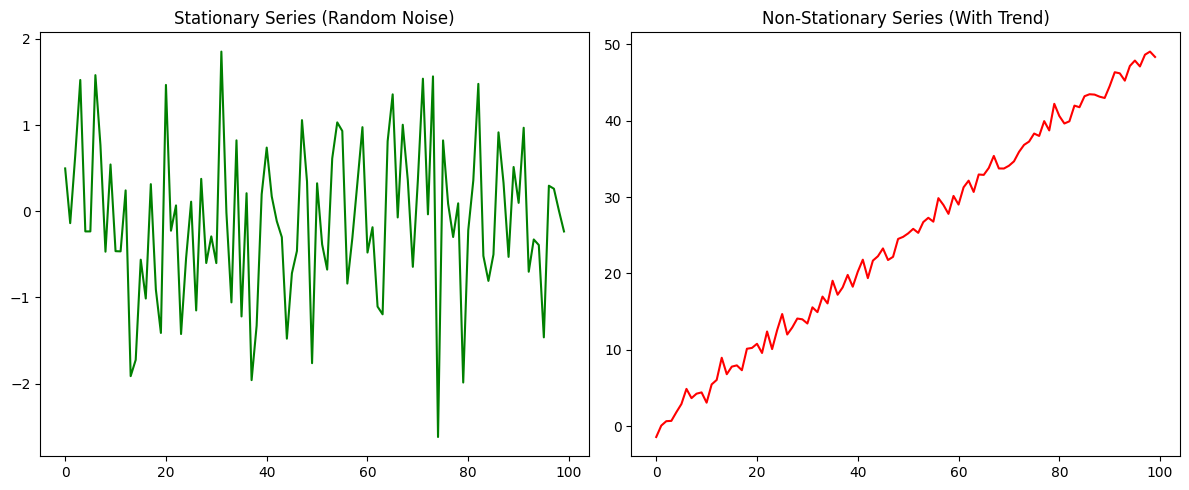


ADF Test for Stationary Series:
Test Statistic: -10.0844
p-value: 0.0000
Series is stationary (reject H₀)

ADF Test for Non-Stationary Series:
Test Statistic: -0.2935
p-value: 0.9264
Series is NOT stationary (fail to reject H₀)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Create a stationary time series (random noise)
np.random.seed(42)
stationary_series = np.random.normal(0, 1, 100)

# Create a non-stationary time series (with trend)
time = np.arange(100)
non_stationary_series = time * 0.5 + np.random.normal(0, 1, 100)

# Plot both series
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(stationary_series, color='green')
plt.title("Stationary Series (Random Noise)")

plt.subplot(1, 2, 2)
plt.plot(non_stationary_series, color='red')
plt.title("Non-Stationary Series (With Trend)")
plt.tight_layout()
plt.show()

# Function to run ADF test
def check_stationarity(series, name):
    result = adfuller(series)
    print(f"\nADF Test for {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("Series is stationary (reject H₀)")
    else:
        print("Series is NOT stationary (fail to reject H₀)")

# Run ADF tests
check_stationarity(stationary_series, "Stationary Series")
check_stationarity(non_stationary_series, "Non-Stationary Series")

In [ ]:
from scipy.stats import shapiro

# Function to run Shapiro-Wilk test
def check_normality(series, name):
    stat, p = shapiro(series)
    print(f"\nShapiro-Wilk Test for {name}:")
    print(f"Test Statistic: {stat:.4f}")
    print(f"p-value: {p:.4f}")
    if p > 0.05:
        print("Series looks Gaussian (fail to reject H₀)")
    else:
        print("Series does not look Gaussian (reject H₀)")

# Run Shapiro-Wilk tests
check_normality(stationary_series, "Stationary Series")
check_normality(non_stationary_series, "Non-Stationary Series")


Shapiro-Wilk Test for Stationary Series:
Test Statistic: 0.9899
p-value: 0.6552
Series looks Gaussian (fail to reject H₀)

Shapiro-Wilk Test for Non-Stationary Series:
Test Statistic: 0.9546
p-value: 0.0017
Series does not look Gaussian (reject H₀)


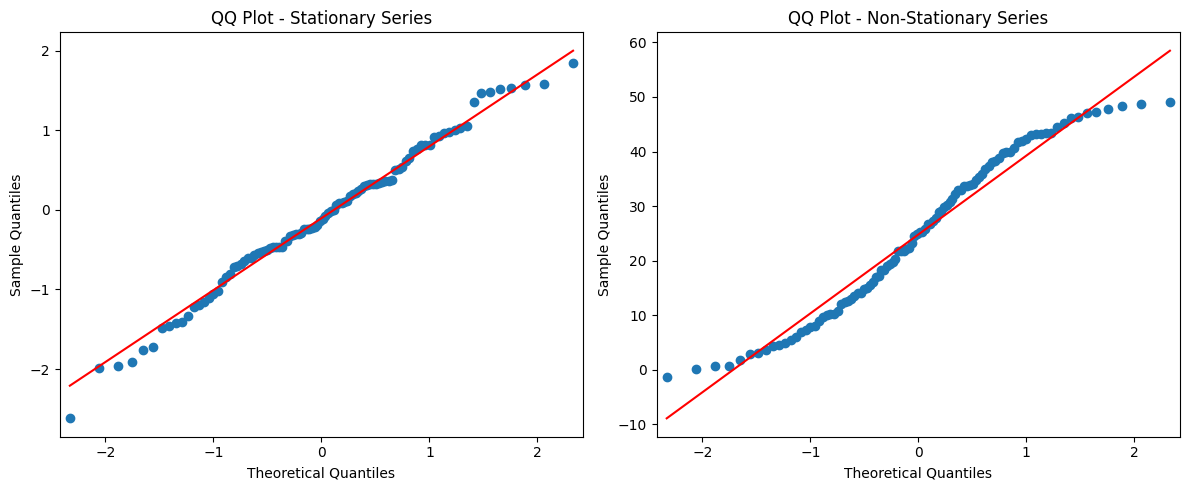

In [ ]:
import statsmodels.api as sm

# Create QQ plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sm.qqplot(stationary_series, line='s', ax=plt.gca())
plt.title("QQ Plot - Stationary Series")

plt.subplot(1, 2, 2)
sm.qqplot(non_stationary_series, line='s', ax=plt.gca())
plt.title("QQ Plot - Non-Stationary Series")

plt.tight_layout()
plt.show()

/tmp/ipython-input-4-1801532618.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series2 = series1.shift(6).fillna(method='bfill')  # Lagged version for cross-correlation


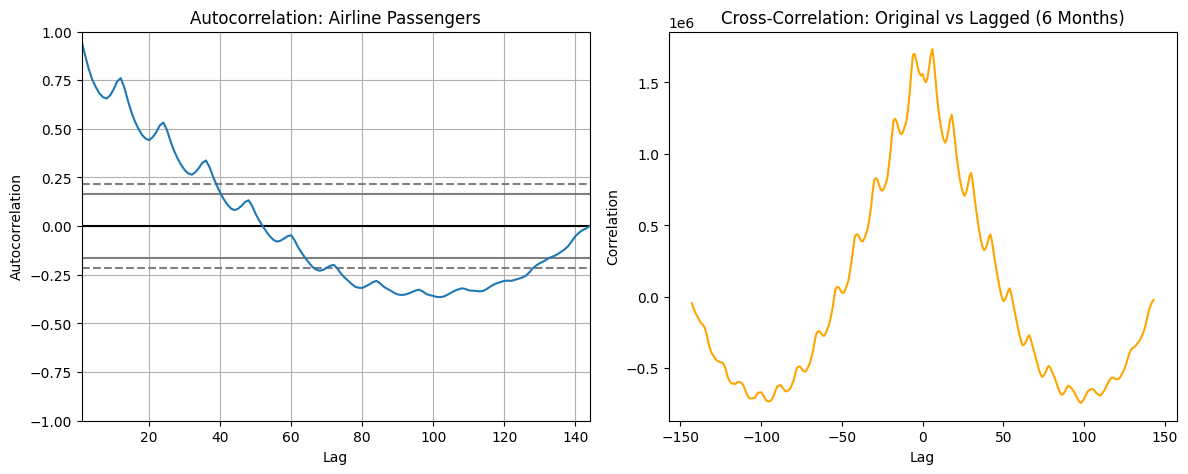

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from scipy.signal import correlate

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Original time series
series1 = df['Passengers']
series2 = series1.shift(6).fillna(method='bfill')  # Lagged version for cross-correlation

# Plot autocorrelation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
autocorrelation_plot(series1)
plt.title("Autocorrelation: Airline Passengers")

# Cross-correlation between original and lagged series
cross_corr = correlate(series1 - series1.mean(), series2 - series2.mean(), mode='full')
lags = np.arange(-len(series1) + 1, len(series1))

plt.subplot(1, 2, 2)
plt.plot(lags, cross_corr, color='orange')
plt.title("Cross-Correlation: Original vs Lagged (6 Months)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

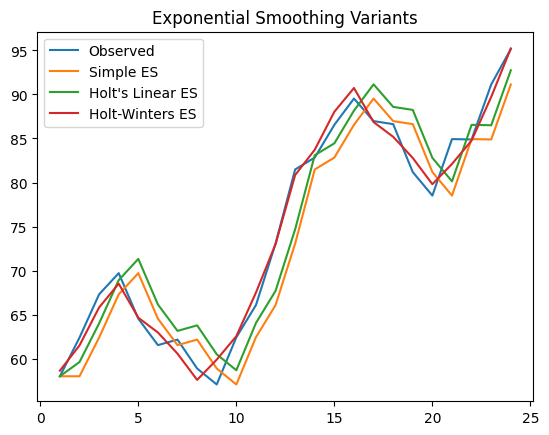

In [ ]:
# Exponential_Smoothing.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Simulate data with trend and seasonality
np.random.seed(42)
time = np.arange(1, 25)
trend = time * 2
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, 24)
y = 50 + trend + seasonality + noise

plt.plot(time, y, label='Observed')

# Simple Exponential Smoothing
model_simple = SimpleExpSmoothing(y).fit()
plt.plot(time, model_simple.fittedvalues, label='Simple ES')

# Holt's Linear Trend Method
model_holt = ExponentialSmoothing(y, trend='add').fit()
plt.plot(time, model_holt.fittedvalues, label="Holt's Linear ES")

# Holt-Winters Seasonal Method
model_hw = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=12).fit()
plt.plot(time, model_hw.fittedvalues, label="Holt-Winters ES")

plt.legend()
plt.title("Exponential Smoothing Variants")
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


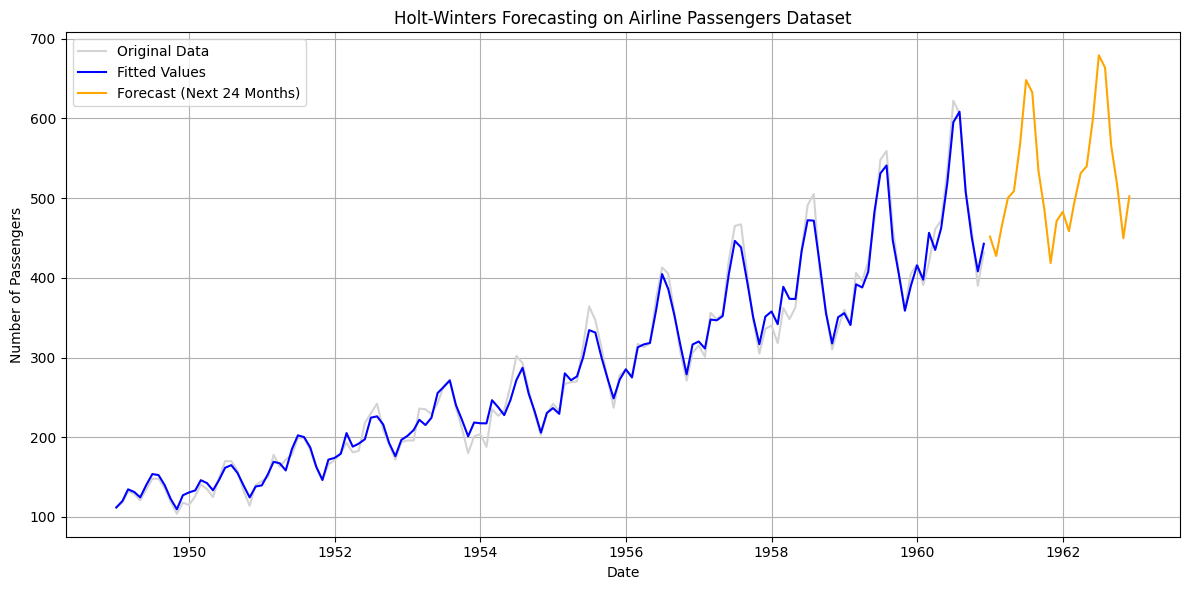

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Step 1: Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Step 2: Fit Holt-Winters model (Additive version)
model = ExponentialSmoothing(df['Passengers'],
                              trend='add',
                              seasonal='add',
                              seasonal_periods=12)

fit = model.fit()

# Step 3: Forecast next 24 months
forecast = fit.forecast(24)

# Step 4: Plot original data, fitted values, and forecast
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Original Data', color='lightgray')
plt.plot(fit.fittedvalues, label='Fitted Values', color='blue')
plt.plot(forecast, label='Forecast (Next 24 Months)', color='orange')
plt.title('Holt-Winters Forecasting on Airline Passengers Dataset')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


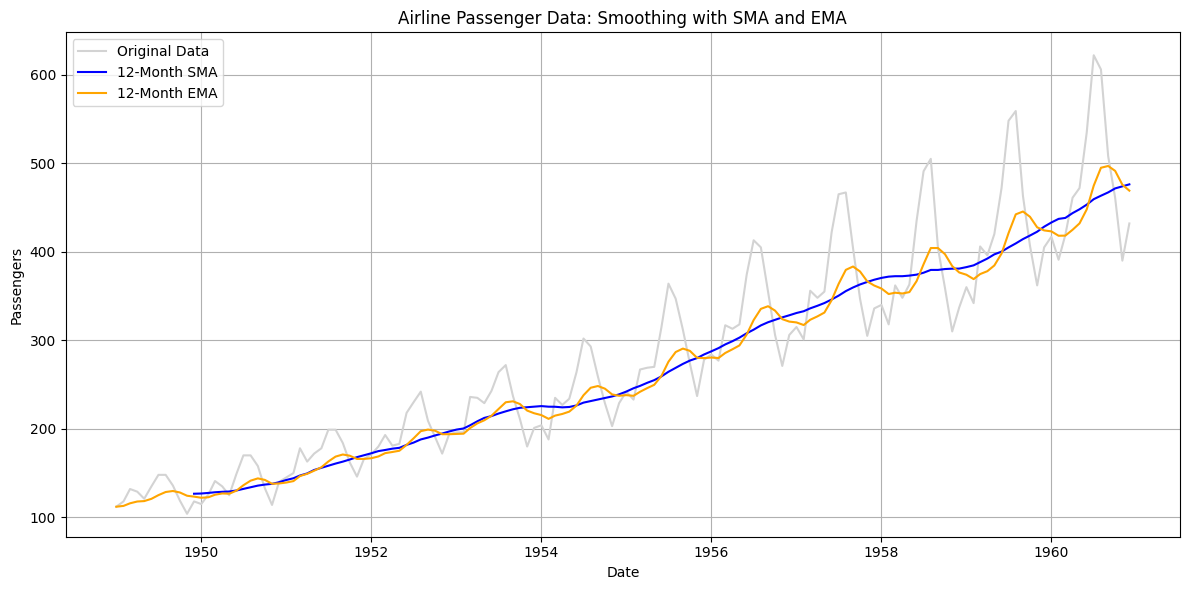

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Calculate moving averages
df['SMA_12'] = df['Passengers'].rolling(window=12).mean()         # 12-month SMA
df['EMA_12'] = df['Passengers'].ewm(span=12, adjust=False).mean() # 12-month EMA

# Plot original and smoothed data
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Original Data', color='lightgray')
plt.plot(df['SMA_12'], label='12-Month SMA', color='blue')
plt.plot(df['EMA_12'], label='12-Month EMA', color='orange')
plt.title('Airline Passenger Data: Smoothing with SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


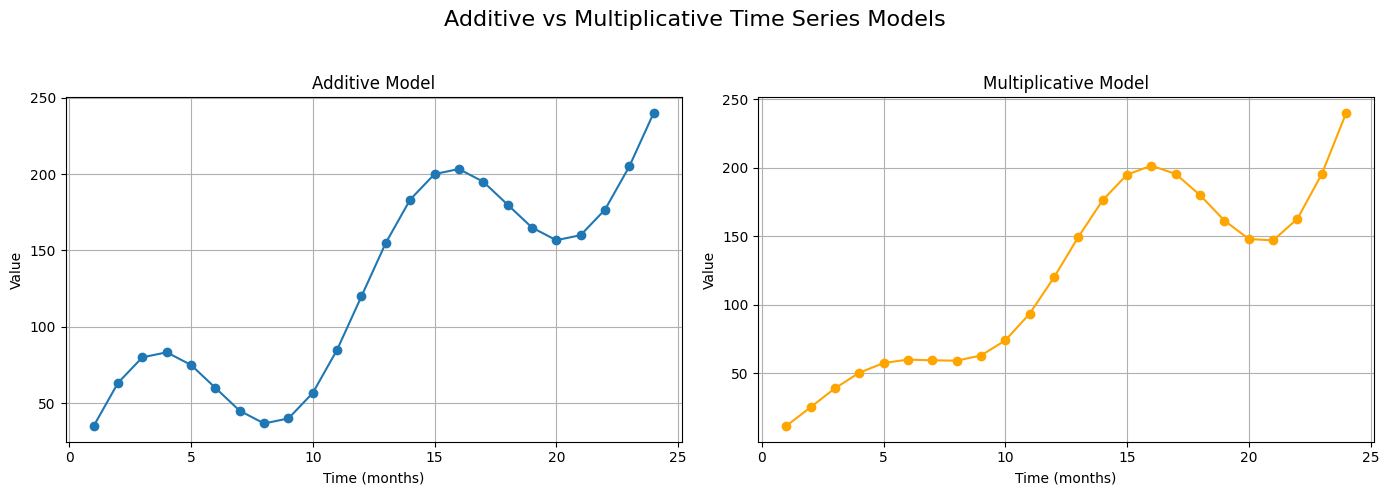

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate time series data
np.random.seed(42)
time = np.arange(1, 25)  # 24 months

# Simulate trend
trend = time * 10

# Simulate seasonality (simple sine wave pattern)
seasonality = 50 * np.sin(2 * np.pi * time / 12)

# Additive model: trend + seasonality
additive = trend + seasonality

# Multiplicative model: trend * (1 + seasonality_percent)
seasonality_percent = 0.3 * np.sin(2 * np.pi * time / 12)  # 30% fluctuation
multiplicative = trend * (1 + seasonality_percent)

# Plotting both models side by side
plt.figure(figsize=(14,5))

# Additive plot
plt.subplot(1,2,1)
plt.plot(time, additive, marker='o')
plt.title("Additive Model")
plt.xlabel("Time (months)")
plt.ylabel("Value")
plt.grid(True)

# Multiplicative plot
plt.subplot(1,2,2)
plt.plot(time, multiplicative, marker='o', color='orange')
plt.title("Multiplicative Model")
plt.xlabel("Time (months)")
plt.ylabel("Value")
plt.grid(True)

plt.suptitle("Additive vs Multiplicative Time Series Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

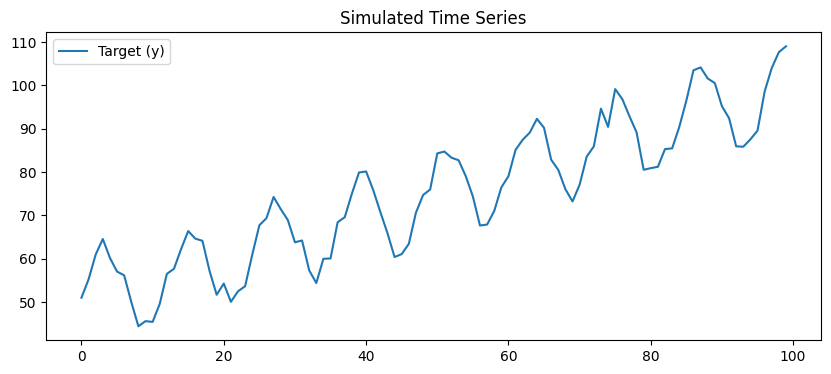

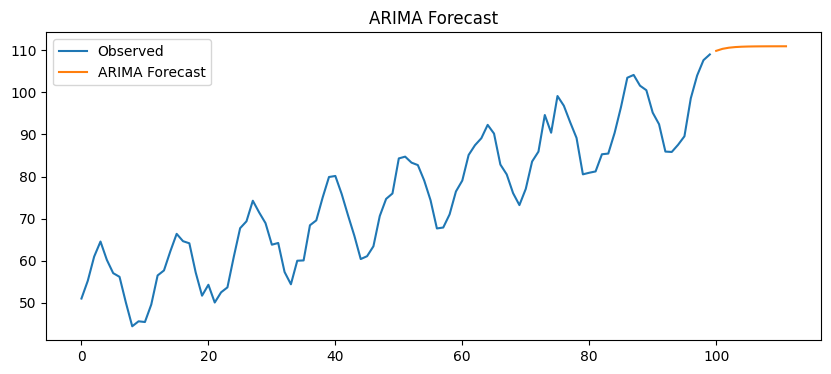

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -278.836
Date:                Sat, 12 Jul 2025   AIC                            563.671
Time:                        07:18:11   BIC                            571.456
Sample:                             0   HQIC                           566.821
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5604      0.199      2.818      0.005       0.171       0.950
ma.L1         -0.1753      0.233     -0.753      0.451      -0.631       0.281
sigma2        16.3320      3.199      5.106      0.0

In [ ]:
# ARIMA_Model.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Simulate data
np.random.seed(42)
n = 100
time = np.arange(n)
trend = time * 0.5
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)
y = 50 + trend + seasonality + noise

# Plot data
plt.figure(figsize=(10,4))
plt.plot(y, label='Target (y)')
plt.legend()
plt.title("Simulated Time Series")
plt.show()

# Fit ARIMA model
model_arima = ARIMA(y, order=(1,1,1))
result_arima = model_arima.fit()
forecast_arima = result_arima.forecast(steps=12)

# Plot forecast
plt.figure(figsize=(10,4))
plt.plot(y, label='Observed')
plt.plot(range(n, n+12), forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

# Print summary
print(result_arima.summary())

In [ ]:
import pandas as pd
df = pd.read_csv("Mik_Pro.csv")

In [ ]:
df.head()

,Year,Milk Production
0,1980,1620
1,1981,1899
2,1982,2015
3,1983,2096
4,1984,2110


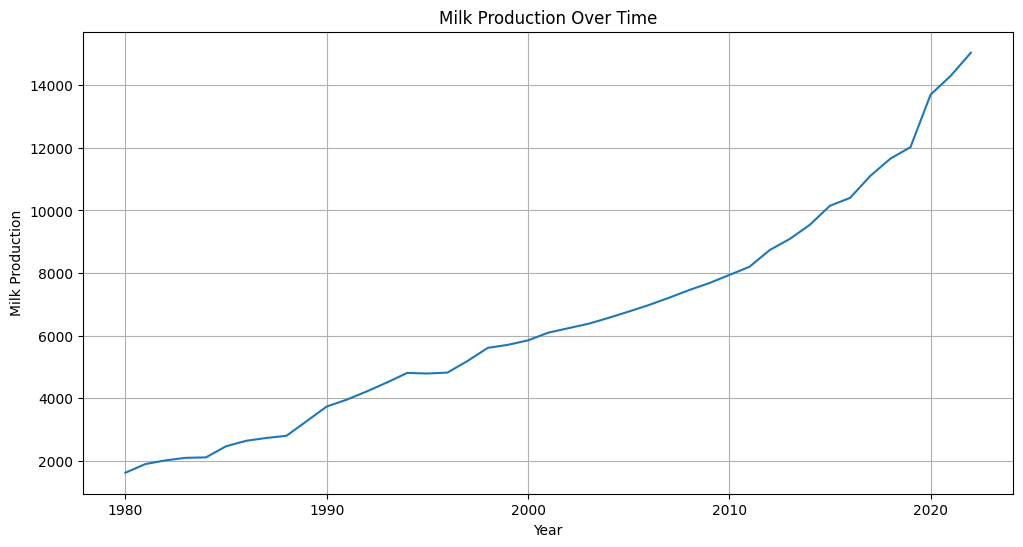

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['Milk Production'])
plt.title('Milk Production Over Time')
plt.xlabel('Year')
plt.ylabel('Milk Production')
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

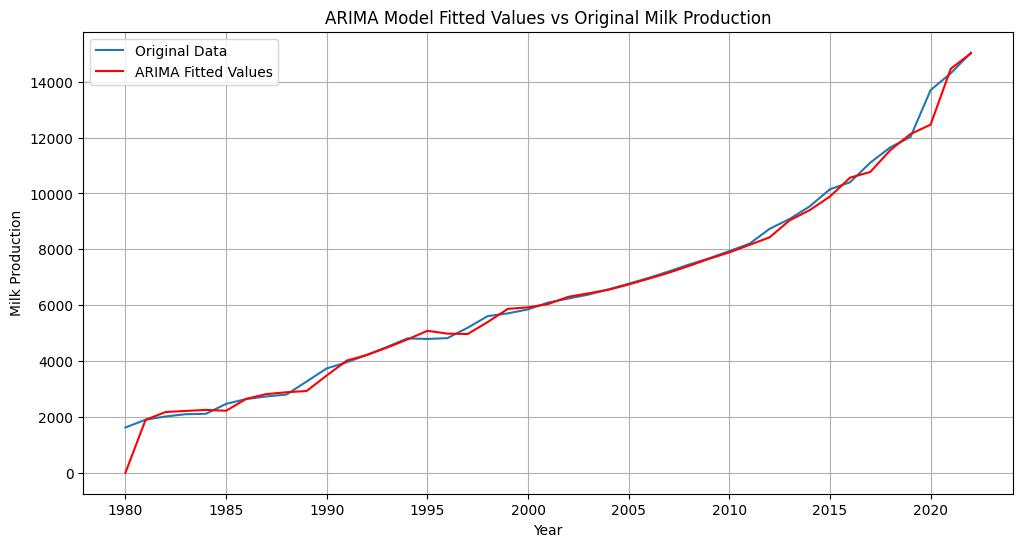

                               SARIMAX Results                                
Dep. Variable:        Milk Production   No. Observations:                   43
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -291.129
Date:                Sat, 12 Jul 2025   AIC                            588.257
Time:                        07:30:17   BIC                            593.470
Sample:                    01-01-1980   HQIC                           590.168
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9896      0.036     27.816      0.000       0.920       1.059
ma.L1         -0.7244      0.226     -3.201      0.001      -1.168      -0.281
sigma2      5.858e+04   6536.934      8.962      0.0

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Convert 'Year' to datetime index for time series analysis
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

# Fit ARIMA model
# Using (1,1,1) as a starting point, this can be optimized later
arima_model = ARIMA(df['Milk Production'], order=(1,1,1))
arima_result = arima_model.fit()

# Get fitted values
fitted_values = arima_result.fittedvalues

# Plot original data and fitted values
plt.figure(figsize=(12, 6))
plt.plot(df['Milk Production'], label='Original Data')
plt.plot(fitted_values, color='red', label='ARIMA Fitted Values')
plt.title('ARIMA Model Fitted Values vs Original Milk Production')
plt.xlabel('Year')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

print(arima_result.summary())

In [ ]:
import pandas as pd
df = pd.read_csv('daily-minimum-temperatures-in-me.csv', on_bad_lines='skip')

In [ ]:
df.head()

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


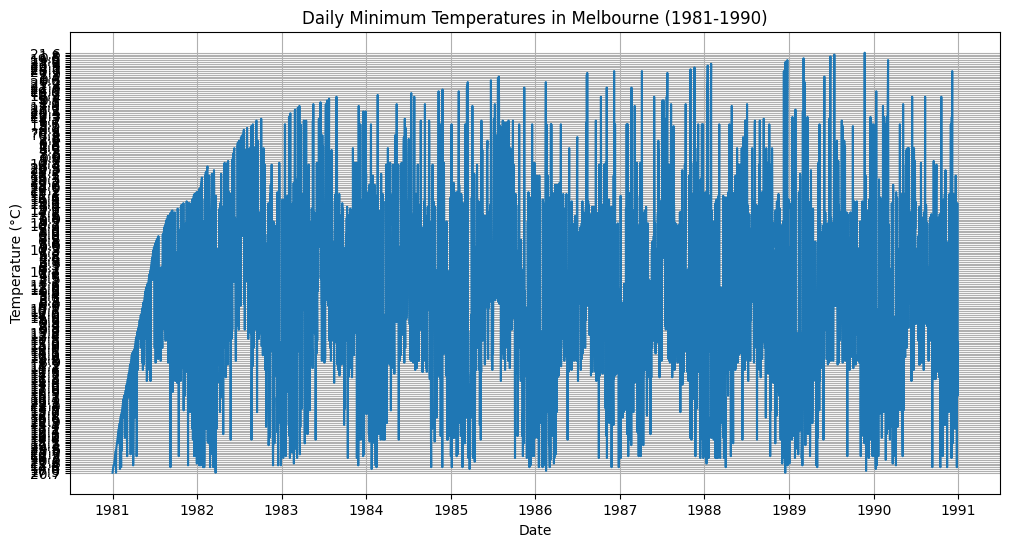

In [ ]:
import matplotlib.pyplot as plt

# Assuming the date column is named 'Date' and the temperature column is named 'Daily minimum temperatures in Melbourne, Australia, 1981-1990'
# We need to convert the 'Date' column to datetime objects and set it as the index for proper time series plotting

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df['Daily minimum temperatures in Melbourne, Australia, 1981-1990'])
plt.title('Daily Minimum Temperatures in Melbourne (1981-1990)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px

fig = px.line(df, y='Daily minimum temperatures in Melbourne, Australia, 1981-1990', title='Daily Minimum Temperatures in Melbourne (1981-1990)')
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Temperature (°C)"
)
fig.show()

In [ ]:
# Clean the temperature column
df['Daily minimum temperatures in Melbourne, Australia, 1981-1990'] = pd.to_numeric(
    df['Daily minimum temperatures in Melbourne, Australia, 1981-1990'], errors='coerce'
)

# Drop rows with NaN values in the temperature column
df.dropna(subset=['Daily minimum temperatures in Melbourne, Australia, 1981-1990'], inplace=True)

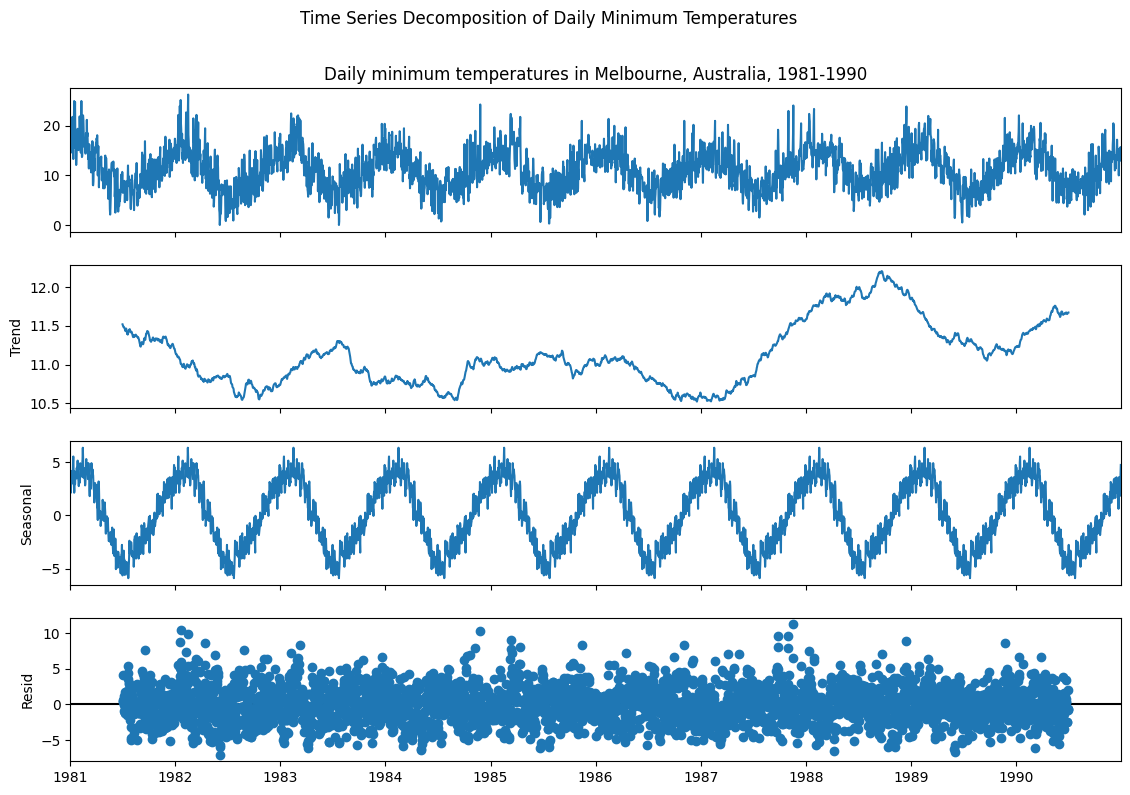

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Decompose the time series
decomposition = seasonal_decompose(df['Daily minimum temperatures in Melbourne, Australia, 1981-1990'], model='additive', period=365)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Daily Minimum Temperatures', y=1.02)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(df['Daily minimum temperatures in Melbourne, Australia, 1981-1990'])

# Print the results
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result[1] <= 0.05:
    print("\nResult: The time series is likely stationary (reject H0)")
else:
    print("\nResult: The time series is likely non-stationary (fail to reject H0)")

ADF Statistic: -4.444653
p-value: 0.000247
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567

Result: The time series is likely stationary (reject H0)


In [ ]:
import pandas as pd
df = pd.read_csv('Mik_Pro.csv')

In [ ]:
df.head()

,Year,Milk Production
0,1980,1620
1,1981,1899
2,1982,2015
3,1983,2096
4,1984,2110


In [ ]:
df.shape

(43, 2)

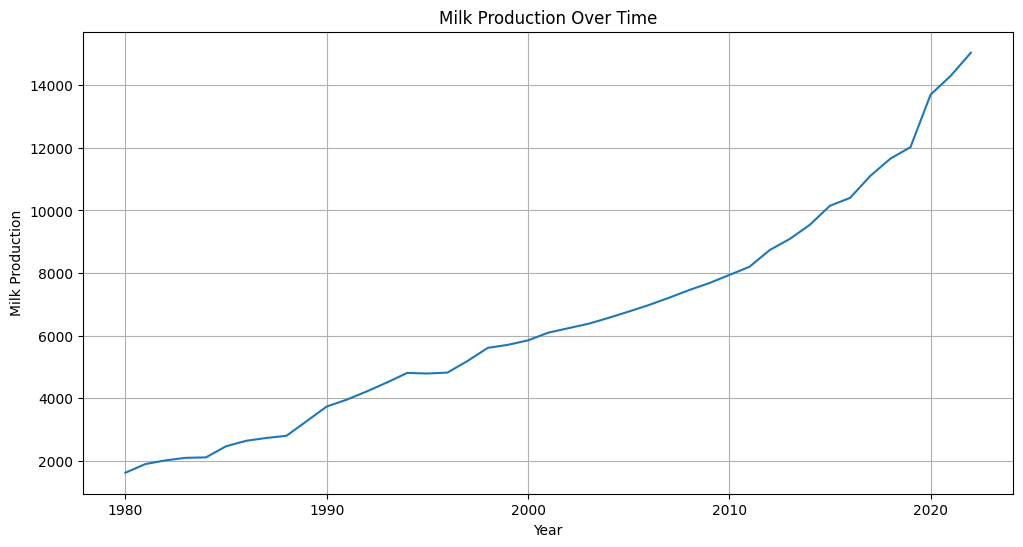

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['Milk Production'])
plt.title('Milk Production Over Time')
plt.xlabel('Year')
plt.ylabel('Milk Production')
plt.grid(True)
plt.show()

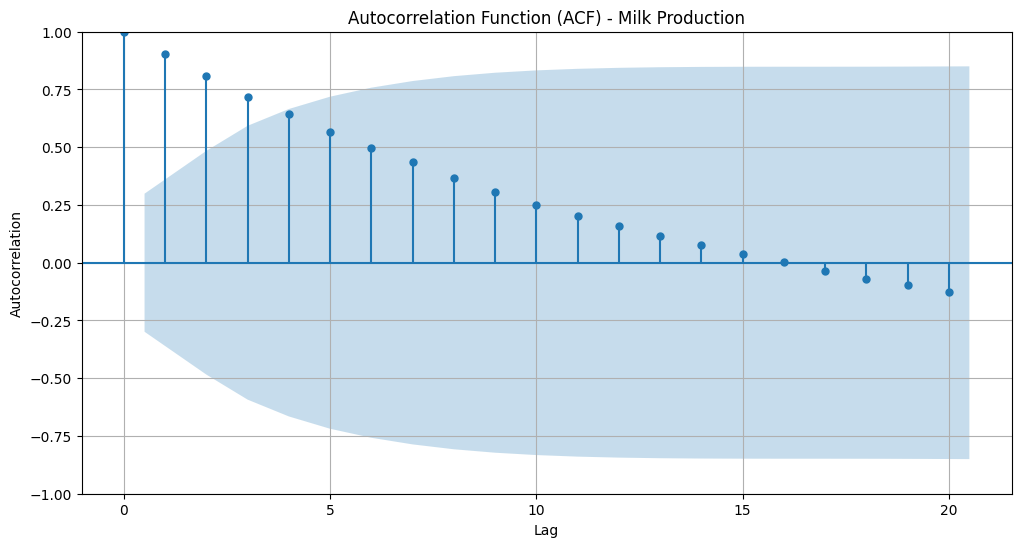

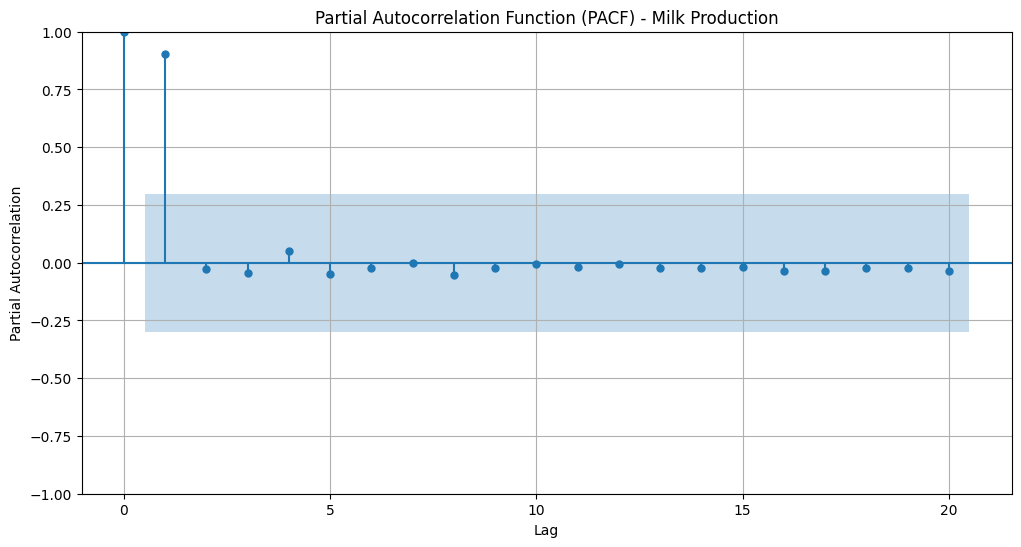

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(df['Milk Production'], lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) - Milk Production')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(df['Milk Production'], lags=20, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) - Milk Production')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Convert 'Year' to datetime index if not already
# This might be redundant if the previous cell already did this, but it ensures the index is datetime
if not isinstance(df.index, pd.DatetimeIndex):
    df['Year'] = pd.to_datetime(df['Year'], format='%Y')
    df.set_index('Year', inplace=True)

# Fit ARIMA model with manually chosen orders (1,1,1)
# (p=1, d=1, q=1)
manual_arima_model = ARIMA(df['Milk Production'], order=(1,1,1))
manual_arima_result = manual_arima_model.fit()

# Print the model summary
print(manual_arima_result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



                               SARIMAX Results                                
Dep. Variable:        Milk Production   No. Observations:                   43
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -291.129
Date:                Sat, 12 Jul 2025   AIC                            588.257
Time:                        09:55:40   BIC                            593.470
Sample:                    01-01-1980   HQIC                           590.168
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9896      0.036     27.816      0.000       0.920       1.059
ma.L1         -0.7244      0.226     -3.201      0.001      -1.168      -0.281
sigma2      5.858e+04   6536.934      8.962      0.0

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.6 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from math import sqrt

# Fit Auto ARIMA model
auto_arima_model = auto_arima(df['Milk Production'], seasonal=True, m=12, # Assuming yearly seasonality for monthly data
                              stepwise=True, suppress_warnings=True, error_action='ignore')

print("Auto ARIMA Model Summary:")
print(auto_arima_model.summary())

# Forecast with Manual ARIMA model (assuming manual_arima_result is available from previous steps)
manual_forecast = manual_arima_result.forecast(steps=12) # Forecast next 12 periods

# Forecast with Auto ARIMA model
auto_arima_forecast = auto_arima_model.predict(n_periods=12) # Forecast next 12 periods

# To compare RMSE, we need actual future values, which we don't have in this dataset.
# For demonstration purposes, let's calculate RMSE on the fitted values (in-sample)
# This is not a true forecast evaluation but shows the model fit to the existing data.

manual_fitted_rmse = sqrt(mean_squared_error(df['Milk Production'], manual_arima_result.fittedvalues))
auto_arima_fitted_rmse = sqrt(mean_squared_error(df['Milk Production'], auto_arima_model.predict_in_sample()))


print(f"\nRMSE (In-Sample) for Manual ARIMA: {manual_fitted_rmse:.4f}")
print(f"RMSE (In-Sample) for Auto ARIMA: {auto_arima_fitted_rmse:.4f}")

# Note: For proper comparison, you would split data into training and testing sets
# and calculate RMSE on the out-of-sample forecasts.

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [31]:

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.arima.model import ARIMA

from pmdarima.arima import auto_arima

from sklearn.metrics import mean_squared_error

# Generate synthetic time series (with trend + seasonality)

np.random.seed(0)

time = pd.date_range(start='2010-01-01', periods=120, freq='M')

seasonal = 10 * np.sin(np.arange(120) * 2 * np.pi / 12)

trend = 0.5 * np.arange(120)

noise = np.random.normal(0, 2, 120)

sales = trend + seasonal + noise

series = pd.Series(sales, index=time)

# ---------------------------------------------

# STEP 1: Plot the series and decompose

# ---------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(series)

plt.title("Monthly Sales Time Series")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

decomp = seasonal_decompose(series, model='additive')

decomp.plot()

plt.suptitle("Time Series Decomposition", fontsize=14)

plt.tight_layout()

plt.show()

# ---------------------------------------------

# STEP 2: Manually choose ARIMA(p,d,q)

# ---------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# First difference to remove trend

diff_series = series.diff().dropna()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plot_acf(diff_series, lags=30, ax=plt.gca())

plt.subplot(1, 2, 2)

plot_pacf(diff_series, lags=30, ax=plt.gca(), method='ywm')

plt.tight_layout()

plt.show()

# Based on ACF/PACF → Try ARIMA(2,1,2)

# Train-test split

train = series[:-12]

test = series[-12:]

model_manual = ARIMA(train, order=(2, 1, 2))

manual_fit = model_manual.fit()

forecast_manual = manual_fit.forecast(steps=12)

# ---------------------------------------------

# STEP 3: Auto ARIMA

# ---------------------------------------------

auto_model = auto_arima(train, seasonal=False, trace=True, suppress_warnings=True)

forecast_auto = auto_model.predict(n_periods=12)

# ---------------------------------------------

# STEP 4: Compare RMSE

# ---------------------------------------------

rmse_manual = np.sqrt(mean_squared_error(test, forecast_manual))

rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))

print(f"\nRMSE of Manual ARIMA(2,1,2): {rmse_manual:.2f}")

print(f"RMSE of Auto ARIMA {auto_model.order}: {rmse_auto:.2f}")

# Plot Forecast Comparison

plt.figure(figsize=(10, 5))

plt.plot(series, label='Original')

plt.plot(test.index, forecast_manual, label='Manual ARIMA Forecast', linestyle='--')

plt.plot(test.index, forecast_auto, label='Auto ARIMA Forecast', linestyle='--')

plt.title("Forecast Comparison")

plt.legend()

plt.show()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [33]:
df = pd.read_excel('online_retail_II.xlsx', engine='openpyxl')

In [34]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Task
Analyze the daily sales data from "online_retail_II.xlsx" using FBProphet. Prepare the data in 'ds' and 'y' format, fit the model, forecast sales for the next 60 days, plot the forecast and its components (trend, weekly, yearly), and interpret the components.

## Prepare daily sales data

### Subtask:
Aggregate the data to daily sales and rename the columns to 'ds' and 'y' as required by Prophet.


**Reasoning**:
I need to convert the 'InvoiceDate' to datetime, calculate the total price for each row, aggregate the data by date to get daily sales, reset the index, and rename the columns to 'ds' and 'y'.



In [35]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date
df['TotalPrice'] = df['Quantity'] * df['Price']
daily_sales = df.groupby('Date')['TotalPrice'].sum().reset_index()
daily_sales.rename(columns={'Date': 'ds', 'TotalPrice': 'y'}, inplace=True)
display(daily_sales.head())

,ds,y
0,2009-12-01,53173.03
1,2009-12-02,62763.59
2,2009-12-03,68093.05
3,2009-12-04,40346.40
4,2009-12-05,9803.05


## Fit fbprophet model

### Subtask:
Initialize and fit the Prophet model to the prepared daily sales data.


**Reasoning**:
Import the Prophet class and instantiate the model, then fit it to the daily sales data.



In [36]:
from prophet import Prophet

# Instantiate Prophet model
# Considering daily data with potential weekly and yearly seasonality
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)

# Fit the model to the daily sales data
model.fit(daily_sales)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu_2jdxql/949o3qmd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu_2jdxql/vqwy43j8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28834', 'data', 'file=/tmp/tmpu_2jdxql/949o3qmd.json', 'init=/tmp/tmpu_2jdxql/vqwy43j8.json', 'output', 'file=/tmp/tmpu_2jdxql/prophet_modelf4evhfie/prophet_model-20250712104139.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:41:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:41:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


**Reasoning**:
The Prophet model has been fitted. Now, forecast the sales for the next 60 days as per the overall task.



In [37]:
# Create a future dataframe for forecasting
future = model.make_future_dataframe(periods=60)

# Make the forecast
forecast = model.predict(future)

# Display the first few rows of the forecast
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,55490.927192,40457.755080,70484.903574
1,2009-12-02,51711.903683,38165.819726,66700.383524
2,2009-12-03,55615.347262,40693.801290,70617.274518
3,2009-12-04,46926.311425,32854.550586,61936.156391
4,2009-12-05,8931.062530,-5790.257291,24003.071893


**Reasoning**:
Plot the forecast along with the original data and display the individual forecast components (trend, weekly, yearly).



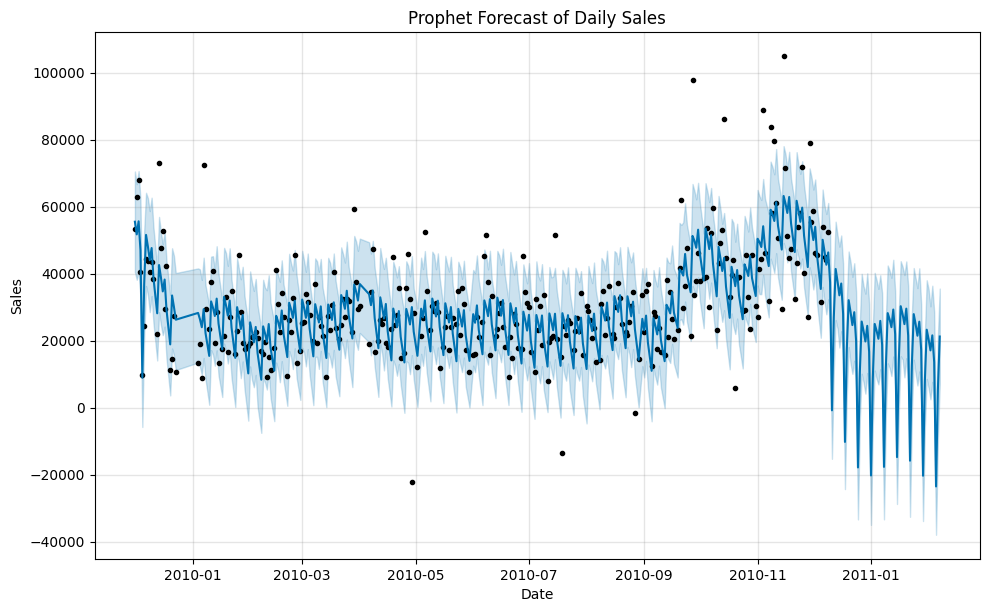

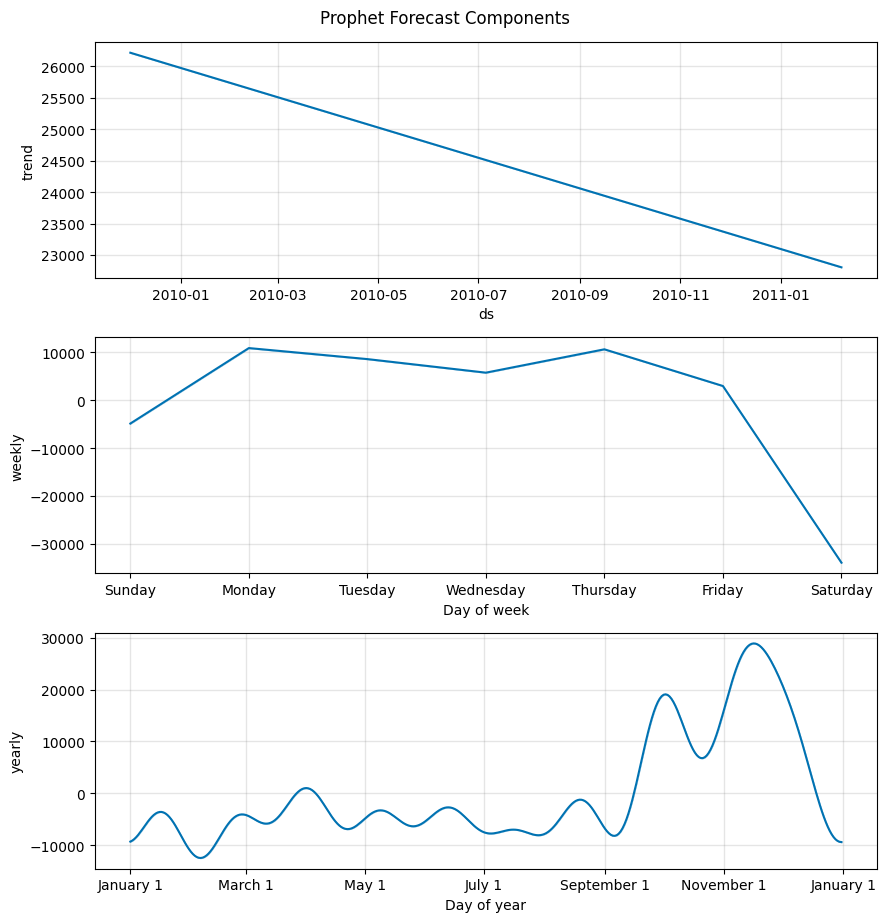

In [38]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast of Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Plot the forecast components
fig2 = model.plot_components(forecast)
plt.suptitle("Prophet Forecast Components", y=1.02)
plt.show()

## Interpret components

### Subtask:
Interpret what the trend, weekly seasonality, and yearly seasonality plots indicate about the daily sales data.


**Reasoning**:
Interpret the trend, weekly, and yearly seasonality components from the previously generated plots to understand the patterns in the daily sales data.



In [39]:
# Interpret the trend
print("Interpretation of Forecast Components:")
print("\nTrend:")
print("The trend plot shows the overall direction of daily sales over time. Observe if there is an upward, downward, or stable trend. Look for any significant shifts or changes in the trend.")

# Interpret the weekly seasonality
print("\nWeekly Seasonality:")
print("The weekly seasonality plot shows the typical pattern of daily sales within a week. Identify which days of the week tend to have higher or lower sales compared to the weekly average.")

# Interpret the yearly seasonality
print("\nYearly Seasonality:")
print("The yearly seasonality plot shows the typical pattern of daily sales within a year. Look for peaks and dips that might correspond to specific months, holidays, or seasons.")

Interpretation of Forecast Components:

Trend:
The trend plot shows the overall direction of daily sales over time. Observe if there is an upward, downward, or stable trend. Look for any significant shifts or changes in the trend.

Weekly Seasonality:
The weekly seasonality plot shows the typical pattern of daily sales within a week. Identify which days of the week tend to have higher or lower sales compared to the weekly average.

Yearly Seasonality:
The yearly seasonality plot shows the typical pattern of daily sales within a year. Look for peaks and dips that might correspond to specific months, holidays, or seasons.


## Summary:

### Data Analysis Key Findings

*   The daily sales data was successfully aggregated and formatted with 'ds' (date) and 'y' (total sales) columns, as required by the FBProphet model.
*   The FBProphet model was initialized with yearly and weekly seasonality and fitted to the daily sales data.
*   A forecast for the next 60 days was generated using the fitted model.
*   The code provided interpretations for the trend, weekly seasonality, and yearly seasonality components, explaining what patterns to look for in the respective plots (e.g., upward/downward trend, higher/lower sales on specific days of the week, peaks/dips during certain months/holidays).

### Insights or Next Steps

*   Analyze the generated plots to identify specific patterns in the trend and seasonalities based on the provided interpretations.
*   Further investigate external factors or events that might explain significant shifts in the trend or pronounced seasonal peaks/dips.


/tmp/ipython-input-40-2358249350.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu_2jdxql/l03s77oj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu_2jdxql/qc6blwrk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36215', 'data', 'file=/tmp/tmpu_2jdxql/l03s77oj.json', 'init=/tmp/tmpu_2jdxql/qc6blwrk.json', 'output', 'file=/tmp/tmpu_2jdxql/prophet_modelyn8kgbmi/prophet_model-20250712104723.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:47:23 

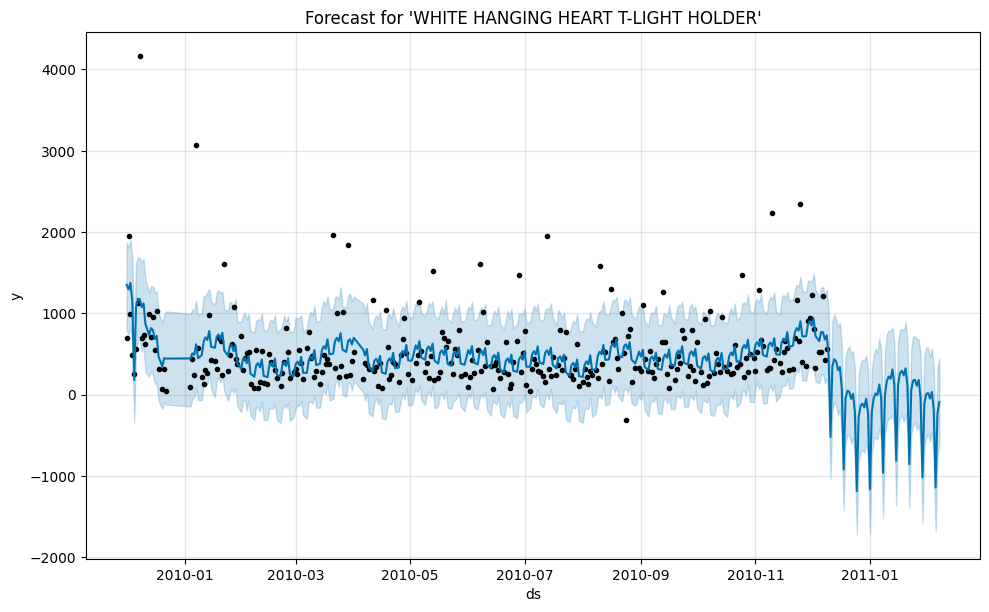

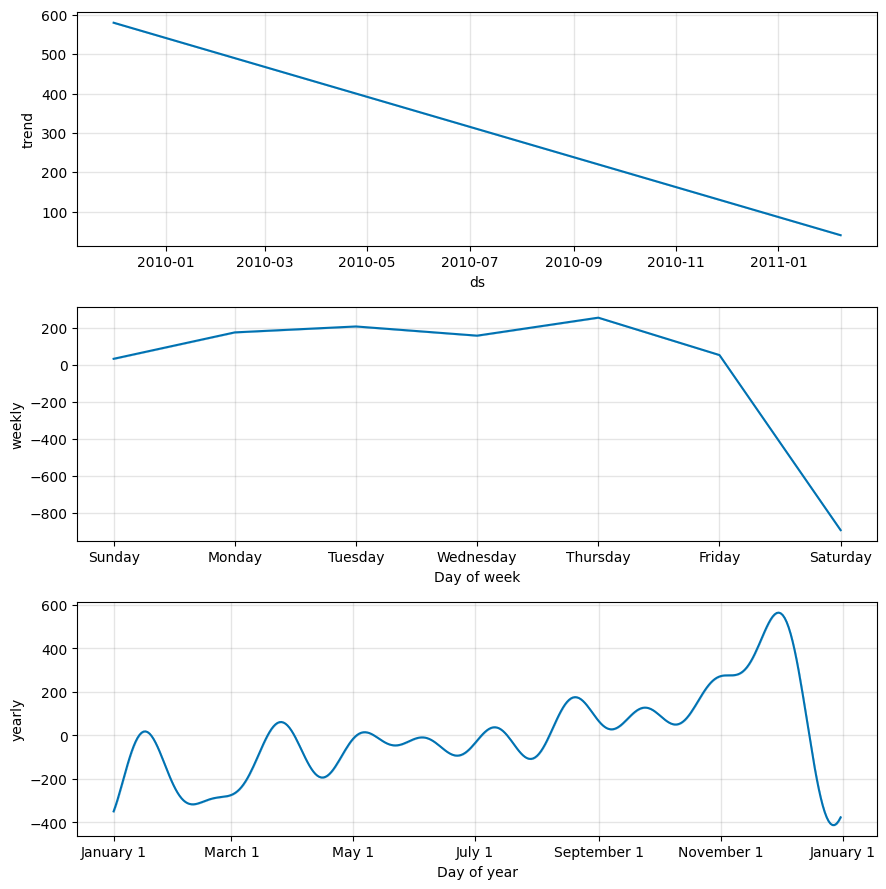

In [40]:
product_df = df[df['Description'] == 'WHITE HANGING HEART T-LIGHT HOLDER']

# Revenue per day for that product
product_df['Revenue'] = product_df['Quantity'] * product_df['Price']
product_sales = product_df.groupby(product_df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index()
product_sales.columns = ['ds', 'y']
product_sales['ds'] = pd.to_datetime(product_sales['ds'])

# Prophet modeling
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(product_sales)

future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

model.plot(forecast)
plt.title("Forecast for 'WHITE HANGING HEART T-LIGHT HOLDER'")
plt.show()

model.plot_components(forecast)
plt.show()

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010
               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000
R²: 0.81
MAE: 4177.05
RMSE: 5956.34


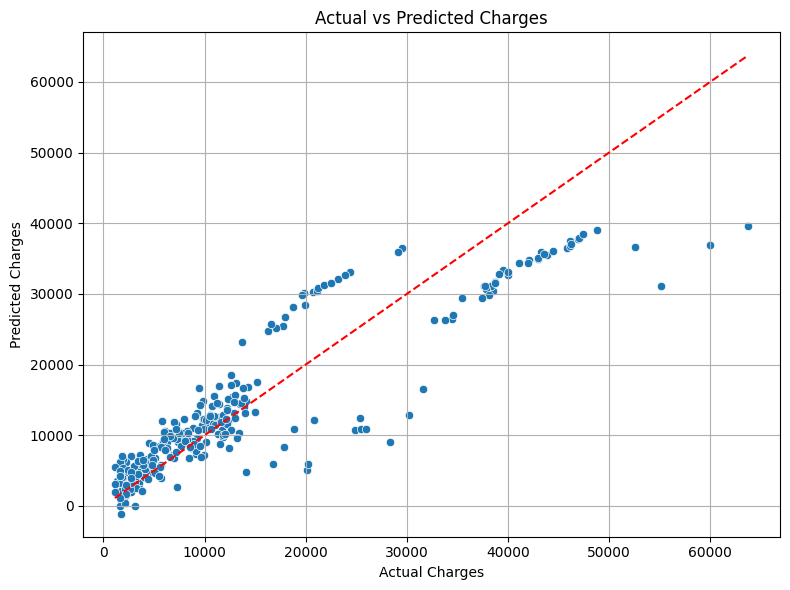

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Step 1: Load Data
df = pd.read_csv("insurance.csv")
df.drop_duplicates(inplace=True)

# Step 2: EDA
print(df.describe())
print(df.corr(numeric_only=True))

# Step 3: Feature Engineering
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 4: Train-Test Split
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test_scaled)
print(f"R²: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Step 7: Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


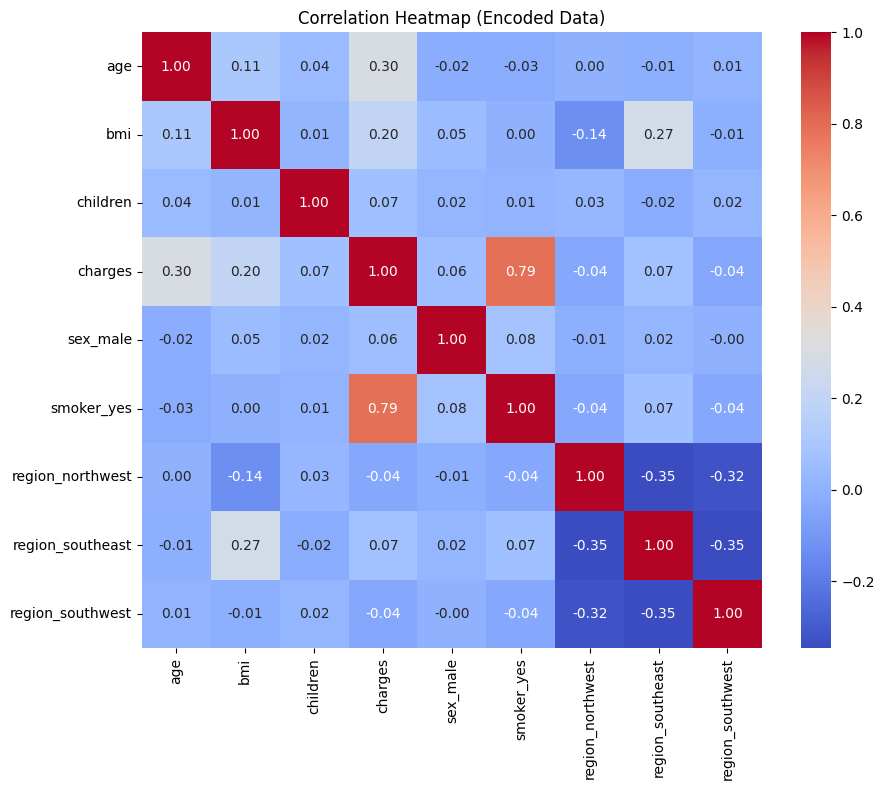

In [45]:
# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Encoded Data)')
plt.show()